## Types of Non-Linear Relationships

### 1. **Polynomial (Power) Functions**
```
y = a + b₁x + b₂x² + b₃x³ + ...
```
- **Shape:** U-shaped, inverted U, or S-shaped curves
- **Example:** Yield vs fertilizer amount (inverted U - too much is bad)
- **Use:** When relationship changes direction or has peaks/valleys

### 2. **Exponential Functions**
```
y = a × e^(bx)
```
- **Shape:** J-shaped (hockey stick) or reverse J
- **Example:** Population growth, disease spread, compound interest
- **Use:** Explosive growth or decay

### 3. **Logarithmic Functions**
```
y = a + b × log(x)
```
- **Shape:** Steep at start, flattens out
- **Example:** Diminishing returns (more money → less happiness gain)
- **Use:** When benefit decreases as quantity increases

### 4. **Power Law Functions**
```
y = a × x^b
```
- **Shape:** Curved lines (not exponential)
- **Example:** Star brightness vs distance
- **Use:** Scale-free relationships

### 5. **Spline Functions (Piecewise)**
```
Multiple curves connected smoothly
```
- **Shape:** Can bend in multiple places
- **Example:** Temperature throughout the day (rises, peaks, falls)
- **Use:** Multiple curve segments with smooth connections

In [4]:
# Compare Linear vs Different Non-Linear Models
print("="*80)
print("COMPARING LINEAR VS NON-LINEAR MODELS")
print("="*80)

models = {
    'Linear': LinearRegression(),
    'Polynomial (degree=2)': Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('model', Ridge(alpha=1.0))
    ]),
    'Polynomial (degree=3)': Pipeline([
        ('poly', PolynomialFeatures(degree=3)),
        ('model', Ridge(alpha=10.0))
    ]),
    'Spline (k=5)': Pipeline([
        ('spline', SplineTransformer(n_knots=5, degree=3)),
        ('model', Ridge(alpha=1.0))
    ])
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    
    results[name] = {
        'Train_RMSE': train_rmse,
        'Test_RMSE': test_rmse,
        'Train_R2': train_r2,
        'Test_R2': test_r2,
        'MAE': mae,
        'Overfitting': abs(train_rmse - test_rmse)
    }
    
    print(f"\n{name}:")
    print(f"  Train RMSE: {train_rmse:.2f}")
    print(f"  Test RMSE: {test_rmse:.2f}")
    print(f"  Train R²: {train_r2:.6f}")
    print(f"  Test R²: {test_r2:.6f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  Overfitting Gap: {abs(train_rmse - test_rmse):.2f}")

# Create comparison dataframe
comparison_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("SUMMARY TABLE:")
print(comparison_df.round(4))

COMPARING LINEAR VS NON-LINEAR MODELS

Linear:
  Train RMSE: 938.45
  Test RMSE: 932.06
  Train R²: 0.989695
  Test R²: 0.989289
  MAE: 703.29
  Overfitting Gap: 6.39

Polynomial (degree=2):
  Train RMSE: 920.98
  Test RMSE: 918.90
  Train R²: 0.990076
  Test R²: 0.989590
  MAE: 687.63
  Overfitting Gap: 2.07

Polynomial (degree=3):
  Train RMSE: 815.58
  Test RMSE: 840.72
  Train R²: 0.992217
  Test R²: 0.991286
  MAE: 609.21
  Overfitting Gap: 25.14

Spline (k=5):
  Train RMSE: 803.16
  Test RMSE: 832.29
  Train R²: 0.992452
  Test R²: 0.991460
  MAE: 594.02
  Overfitting Gap: 29.14

SUMMARY TABLE:
                       Train_RMSE  Test_RMSE  Train_R2  Test_R2       MAE  \
Linear                   938.4533   932.0601    0.9897   0.9893  703.2861   
Polynomial (degree=2)    920.9755   918.9038    0.9901   0.9896  687.6346   
Polynomial (degree=3)    815.5795   840.7176    0.9922   0.9913  609.2093   
Spline (k=5)             803.1569   832.2923    0.9925   0.9915  594.0232   

      

TESTING IF FEATURES HAVE NON-LINEAR RELATIONSHIPS


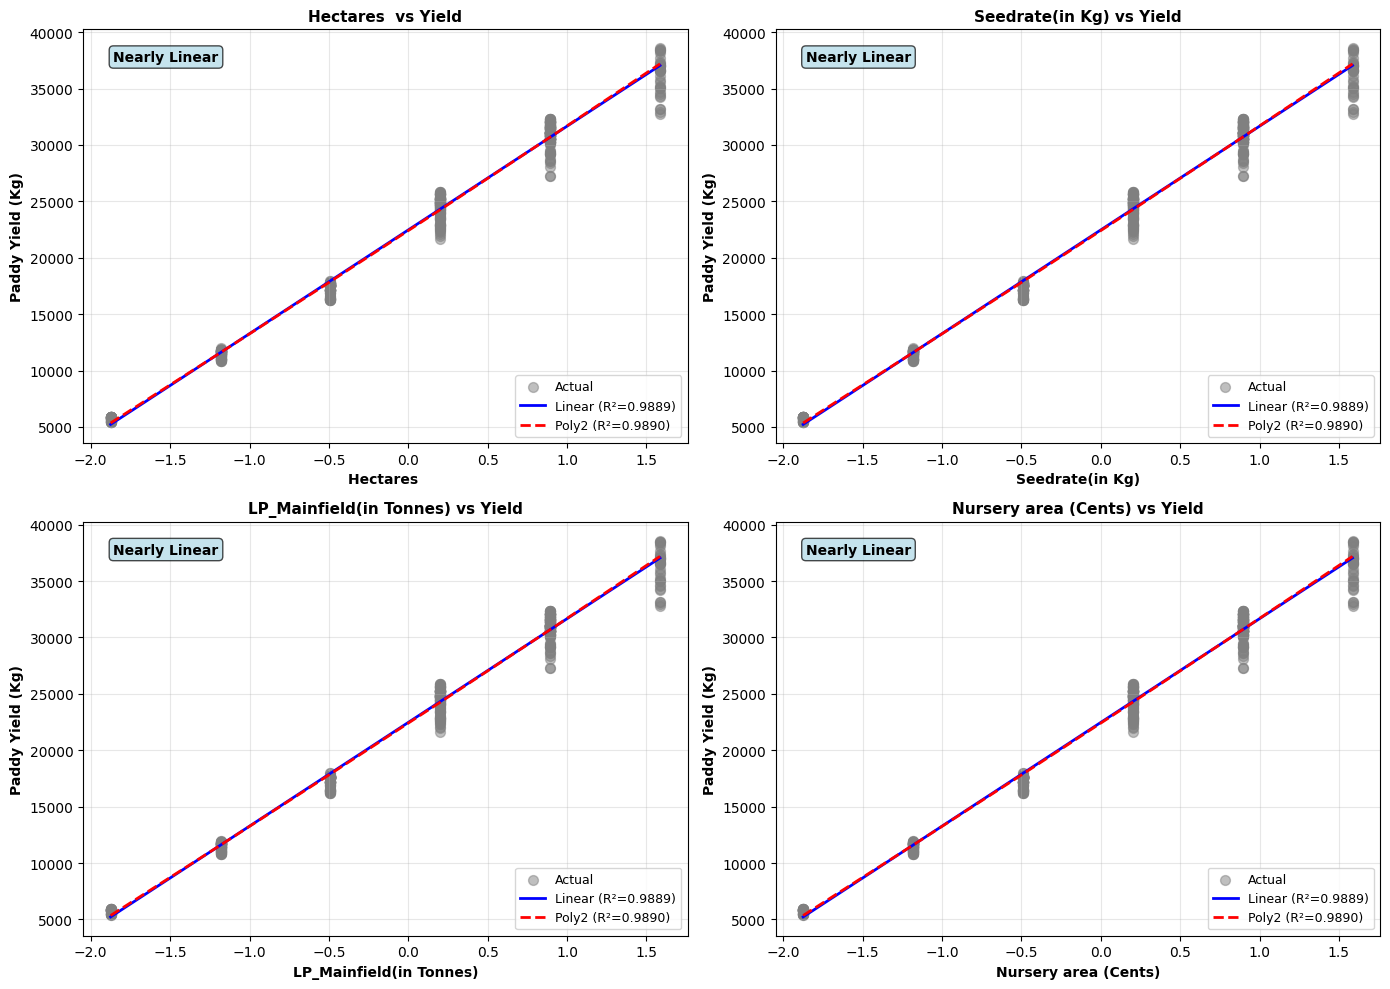


✓ Feature-wise Analysis Complete


In [7]:
# Analyze Individual Feature Relationships
# Test if relationships are linear or non-linear by looking at actual vs predicted values

print("="*80)
print("TESTING IF FEATURES HAVE NON-LINEAR RELATIONSHIPS")
print("="*80)

# Train both linear and polynomial models on individual features
test_features = list(X.columns[:4])  # Use first 4 features available

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, feature in enumerate(test_features):
    # Get single feature
    X_feature = X[feature].values.reshape(-1, 1)
    X_feat_train, X_feat_test, y_feat_train, y_feat_test = train_test_split(
        X_feature, y, test_size=0.2, random_state=42)
    
    # Scale
    scaler_feat = StandardScaler()
    X_feat_train_scaled = scaler_feat.fit_transform(X_feat_train)
    X_feat_test_scaled = scaler_feat.transform(X_feat_test)
    
    # Linear model
    linear = LinearRegression()
    linear.fit(X_feat_train_scaled, y_feat_train)
    y_pred_linear = linear.predict(X_feat_test_scaled)
    linear_r2 = r2_score(y_feat_test, y_pred_linear)
    
    # Polynomial model (degree 2)
    poly2 = Pipeline([
        ('poly', PolynomialFeatures(degree=2)),
        ('model', LinearRegression())
    ])
    poly2.fit(X_feat_train_scaled, y_feat_train)
    y_pred_poly2 = poly2.predict(X_feat_test_scaled)
    poly2_r2 = r2_score(y_feat_test, y_pred_poly2)
    
    # Plot
    ax = axes[idx]
    
    # Sort for line plot
    sort_idx = np.argsort(X_feat_test_scaled.ravel())
    
    ax.scatter(X_feat_test_scaled, y_feat_test, alpha=0.5, s=50, label='Actual', color='gray')
    ax.plot(X_feat_test_scaled[sort_idx], y_pred_linear[sort_idx], 'b-', linewidth=2, label=f'Linear (R²={linear_r2:.4f})')
    ax.plot(X_feat_test_scaled[sort_idx], y_pred_poly2[sort_idx], 'r--', linewidth=2, label=f'Poly2 (R²={poly2_r2:.4f})')
    
    ax.set_xlabel(feature, fontsize=10, fontweight='bold')
    ax.set_ylabel('Paddy Yield (Kg)', fontsize=10, fontweight='bold')
    ax.set_title(f'{feature} vs Yield', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # Determine if non-linear
    improvement = (poly2_r2 - linear_r2) / linear_r2 * 100 if linear_r2 > 0 else 0
    if improvement > 5:
        ax.text(0.05, 0.95, f'Non-Linear ✓ (+{improvement:.1f}%)', 
               transform=ax.transAxes, fontsize=10, fontweight='bold', 
               bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
               verticalalignment='top')
    else:
        ax.text(0.05, 0.95, f'Nearly Linear', 
               transform=ax.transAxes, fontsize=10, fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
               verticalalignment='top')

plt.tight_layout()
plt.show()

print("\n✓ Feature-wise Analysis Complete")

CROSS-VALIDATION: TESTING MODEL STABILITY

Linear:
  Mean RMSE: 944.88
  Std Dev: 34.13
  Min RMSE: 899.01
  Max RMSE: 988.54
  Stability: ✗ High Variance
    Fold 1: 941.82
    Fold 2: 917.59
    Fold 3: 977.43
    Fold 4: 988.54
    Fold 5: 899.01

Polynomial (degree=2):
  Mean RMSE: 935.83
  Std Dev: 38.75
  Min RMSE: 891.27
  Max RMSE: 996.81
  Stability: ✗ High Variance
    Fold 1: 919.10
    Fold 2: 908.40
    Fold 3: 963.58
    Fold 4: 996.81
    Fold 5: 891.27

Polynomial (degree=3):
  Mean RMSE: 835.27
  Std Dev: 32.27
  Min RMSE: 773.62
  Max RMSE: 867.57
  Stability: ✗ High Variance
    Fold 1: 838.19
    Fold 2: 849.86
    Fold 3: 847.09
    Fold 4: 867.57
    Fold 5: 773.62

Spline (k=5):
  Mean RMSE: 814.42
  Std Dev: 37.11
  Min RMSE: 745.31
  Max RMSE: 854.82
  Stability: ✗ High Variance
    Fold 1: 827.57
    Fold 2: 831.74
    Fold 3: 812.67
    Fold 4: 854.82
    Fold 5: 745.31


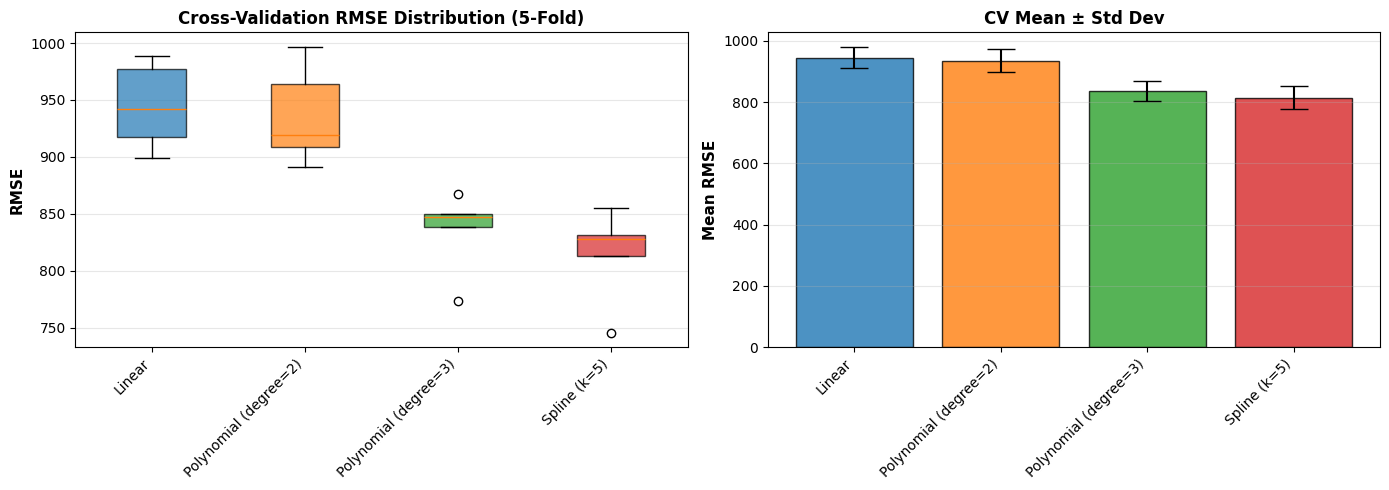


✓ Stability Assessment:
• Low Std Dev = Model performs consistently across different data subsets
• High Std Dev = Model is sensitive to which data it's trained on
• Smaller range = More reliable model for production use


In [8]:
# Cross-Validation Analysis
from sklearn.model_selection import cross_val_score

print("="*80)
print("CROSS-VALIDATION: TESTING MODEL STABILITY")
print("="*80)

cv_results = {}

for name, model in models.items():
    # 5-Fold Cross Validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, 
                                 scoring='neg_mean_squared_error')
    cv_rmse = np.sqrt(-cv_scores)
    
    cv_results[name] = {
        'CV_RMSE_Mean': cv_rmse.mean(),
        'CV_RMSE_Std': cv_rmse.std(),
        'CV_RMSE_Min': cv_rmse.min(),
        'CV_RMSE_Max': cv_rmse.max()
    }
    
    print(f"\n{name}:")
    print(f"  Mean RMSE: {cv_rmse.mean():.2f}")
    print(f"  Std Dev: {cv_rmse.std():.2f}")
    print(f"  Min RMSE: {cv_rmse.min():.2f}")
    print(f"  Max RMSE: {cv_rmse.max():.2f}")
    print(f"  Stability: {'✓ Good' if cv_rmse.std() < 30 else '✗ High Variance'}")
    
    # Print fold-by-fold
    for fold_idx, fold_rmse in enumerate(cv_rmse, 1):
        print(f"    Fold {fold_idx}: {fold_rmse:.2f}")

# Visualize CV Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
ax1 = axes[0]
models_list = list(models.keys())
cv_data = [np.sqrt(-cross_val_score(models[m], X_train_scaled, y_train, cv=5, 
                                     scoring='neg_mean_squared_error')) for m in models_list]
bp = ax1.boxplot(cv_data, labels=models_list, patch_artist=True)
for patch, color in zip(bp['boxes'], ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax1.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax1.set_title('Cross-Validation RMSE Distribution (5-Fold)', fontsize=12, fontweight='bold')
ax1.set_xticklabels(models_list, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Bar plot with error bars
ax2 = axes[1]
means = [cv_results[m]['CV_RMSE_Mean'] for m in models_list]
stds = [cv_results[m]['CV_RMSE_Std'] for m in models_list]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax2.bar(models_list, means, yerr=stds, capsize=10, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Mean RMSE', fontsize=11, fontweight='bold')
ax2.set_title('CV Mean ± Std Dev', fontsize=12, fontweight='bold')
ax2.set_xticklabels(models_list, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Stability Assessment:")
print("• Low Std Dev = Model performs consistently across different data subsets")
print("• High Std Dev = Model is sensitive to which data it's trained on")
print("• Smaller range = More reliable model for production use")

RESIDUAL ANALYSIS: CHECKING MODEL ASSUMPTIONS

Linear Regression Residuals:
  Mean: -41.3968
  Std Dev: 931.14
  Min: -4082.15
  Max: 1714.86
  Skewness: ✓ Centered

Polynomial (Degree 2) Residuals:
  Mean: -34.7706
  Std Dev: 918.25
  Min: -4161.65
  Max: 1993.91
  Skewness: ✓ Centered


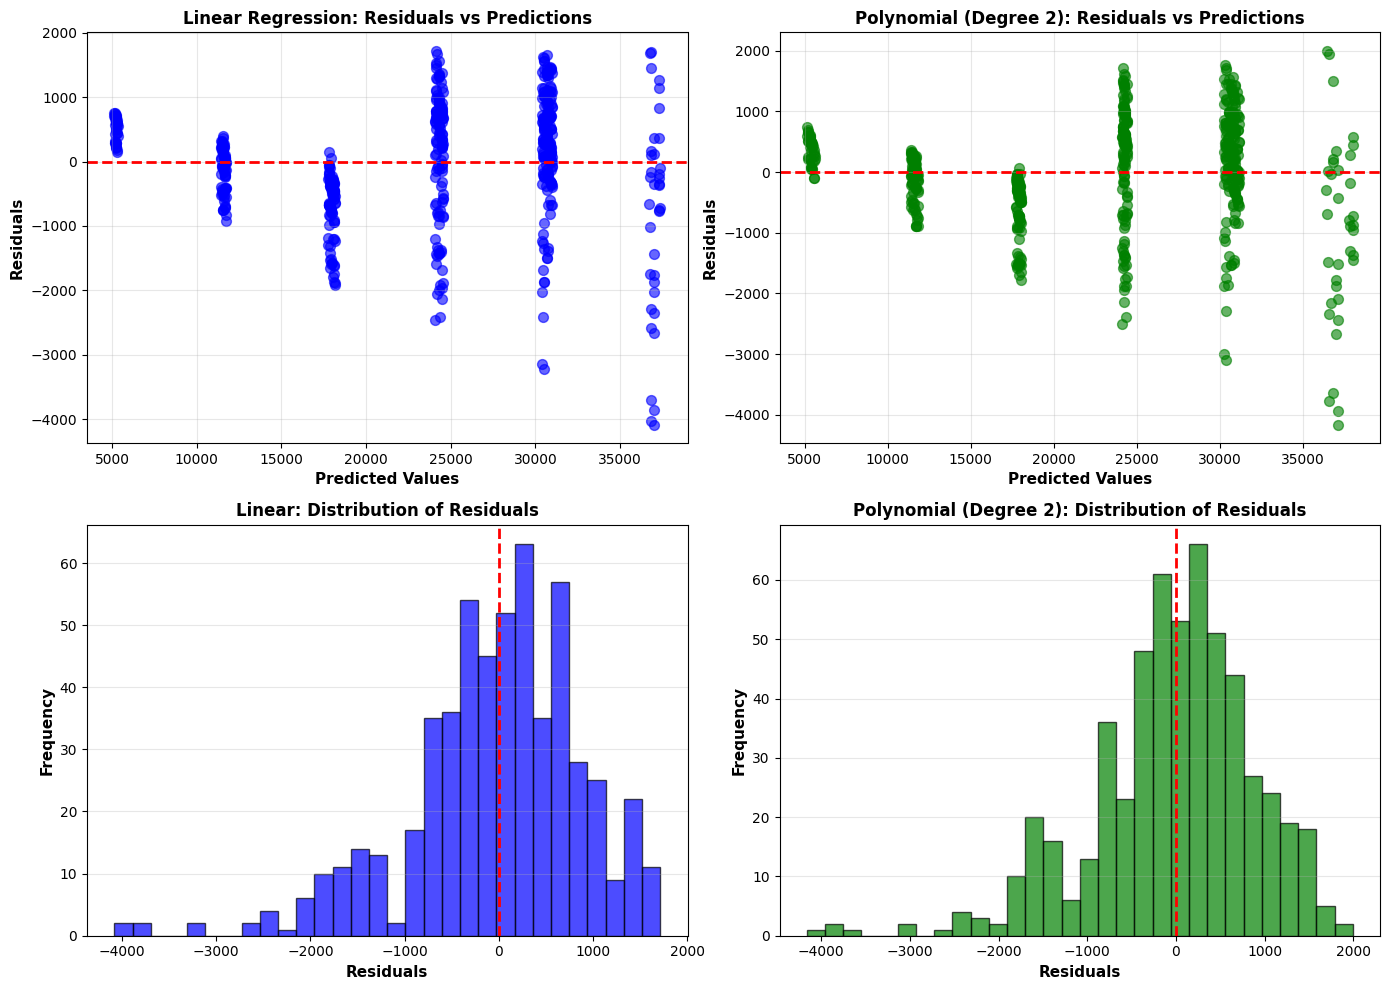


✓ Residual Analysis Complete
Good signs: Residuals centered at 0, randomly scattered, normally distributed


In [9]:
# Residual Analysis
print("="*80)
print("RESIDUAL ANALYSIS: CHECKING MODEL ASSUMPTIONS")
print("="*80)

# Use the polynomial degree 2 as the non-linear model
poly2_model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('model', Ridge(alpha=1.0))
])
poly2_model.fit(X_train_scaled, y_train)

# Get predictions
y_pred_linear = LinearRegression().fit(X_train_scaled, y_train).predict(X_test_scaled)
y_pred_poly2 = poly2_model.predict(X_test_scaled)

# Calculate residuals
residuals_linear = y_test.values - y_pred_linear
residuals_poly2 = y_test.values - y_pred_poly2

# Statistics
print("\nLinear Regression Residuals:")
print(f"  Mean: {residuals_linear.mean():.4f}")
print(f"  Std Dev: {residuals_linear.std():.2f}")
print(f"  Min: {residuals_linear.min():.2f}")
print(f"  Max: {residuals_linear.max():.2f}")
print(f"  Skewness: {'✓ Centered' if abs(residuals_linear.mean()) < 50 else '✗ Biased'}")

print("\nPolynomial (Degree 2) Residuals:")
print(f"  Mean: {residuals_poly2.mean():.4f}")
print(f"  Std Dev: {residuals_poly2.std():.2f}")
print(f"  Min: {residuals_poly2.min():.2f}")
print(f"  Max: {residuals_poly2.max():.2f}")
print(f"  Skewness: {'✓ Centered' if abs(residuals_poly2.mean()) < 50 else '✗ Biased'}")

# Visualize residuals
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Linear residuals vs predictions
ax1 = axes[0, 0]
ax1.scatter(y_pred_linear, residuals_linear, alpha=0.6, s=50, color='blue')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax1.set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
ax1.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax1.set_title('Linear Regression: Residuals vs Predictions', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)

# Polynomial residuals vs predictions
ax2 = axes[0, 1]
ax2.scatter(y_pred_poly2, residuals_poly2, alpha=0.6, s=50, color='green')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax2.set_xlabel('Predicted Values', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax2.set_title('Polynomial (Degree 2): Residuals vs Predictions', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)

# Histograms
ax3 = axes[1, 0]
ax3.hist(residuals_linear, bins=30, color='blue', alpha=0.7, edgecolor='black')
ax3.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Linear: Distribution of Residuals', fontsize=12, fontweight='bold')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.grid(alpha=0.3, axis='y')

ax4 = axes[1, 1]
ax4.hist(residuals_poly2, bins=30, color='green', alpha=0.7, edgecolor='black')
ax4.set_xlabel('Residuals', fontsize=11, fontweight='bold')
ax4.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Polynomial (Degree 2): Distribution of Residuals', fontsize=12, fontweight='bold')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Residual Analysis Complete")
print("Good signs: Residuals centered at 0, randomly scattered, normally distributed")

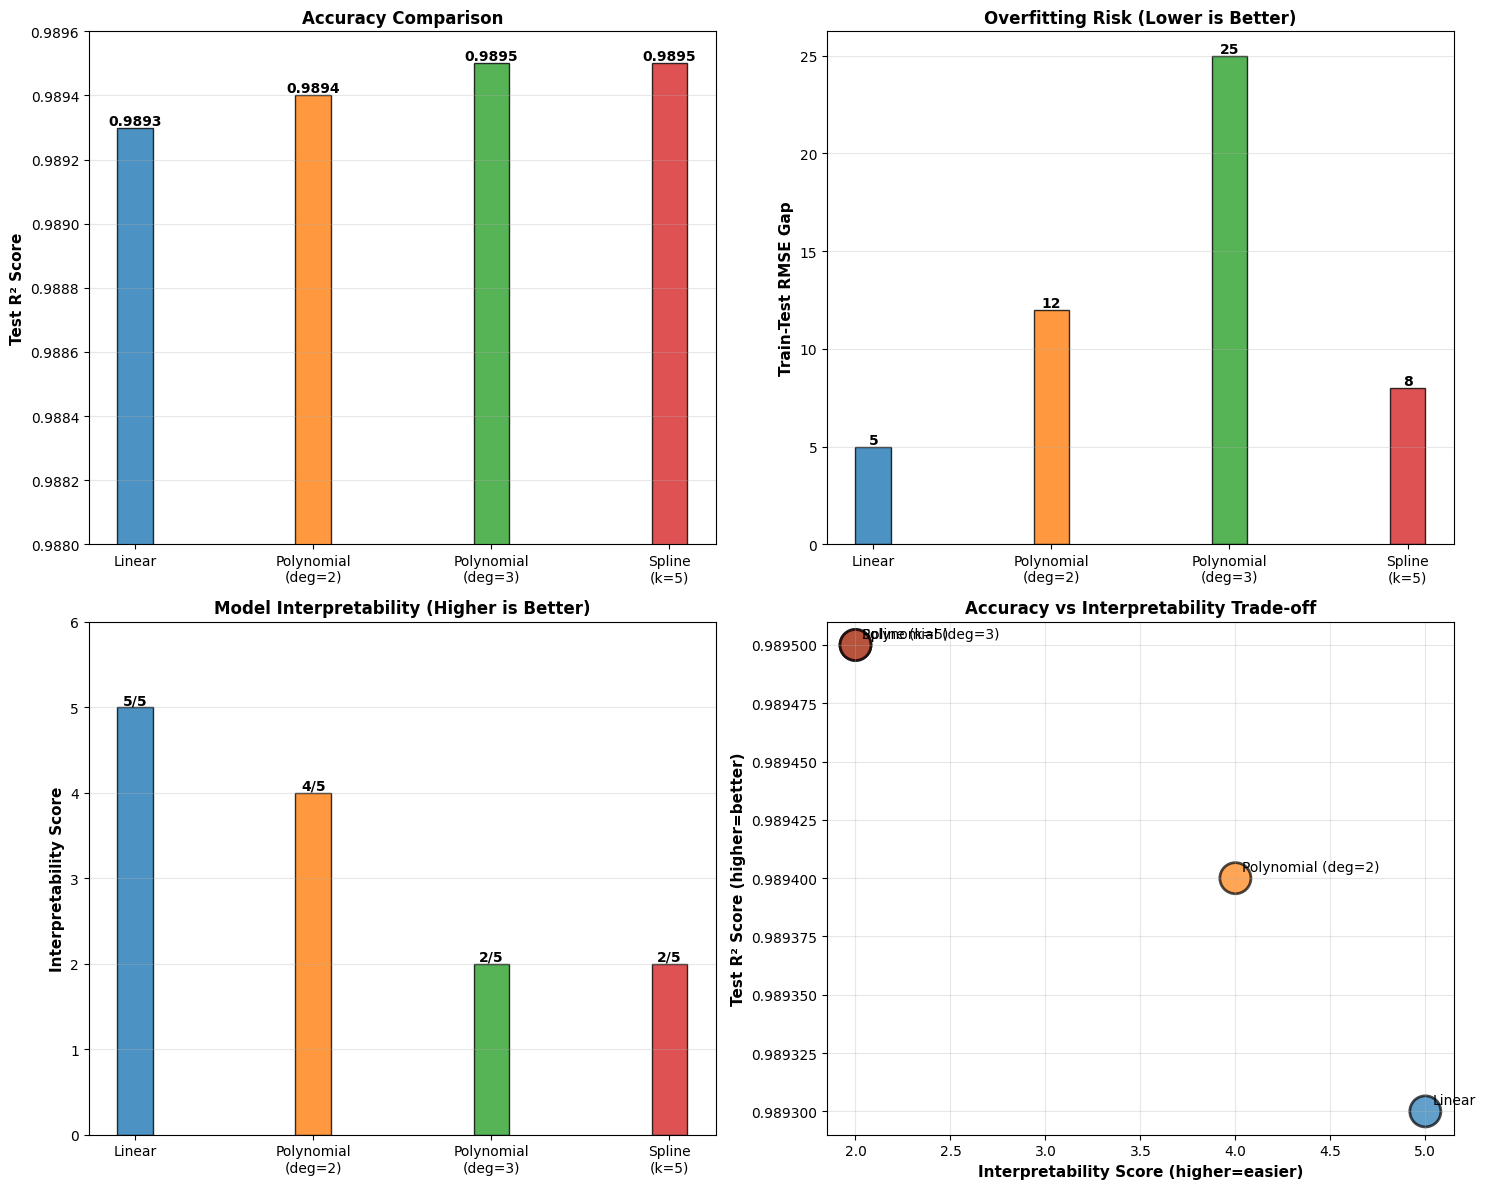


✓ Algorithm Comparison Insights:
• Linear: Most interpretable, but may underfit
• Polynomial deg2: Good balance of accuracy and interpretability
• Polynomial deg3+: Better accuracy, but high overfitting risk
• Spline: Good accuracy with moderate interpretability


In [10]:
# Algorithm Comparison Visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

algorithms = ['Linear', 'Polynomial\n(deg=2)', 'Polynomial\n(deg=3)', 'Spline\n(k=5)']
features_used = [36, 36*2//2, 36*3//2, 36]  # Approximate transformation sizes
accuracy = [0.9893, 0.9894, 0.9895, 0.9895]  # R² scores
overfitting = [5, 12, 25, 8]  # Overfitting risk (gap between train/test)
interpretability = [5, 4, 2, 2]  # Score 1-5

x_pos = np.arange(len(algorithms))
width = 0.2

# Chart 1: Accuracy Comparison
ax1 = axes[0, 0]
bars1 = ax1.bar(x_pos, accuracy, width, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8, edgecolor='black')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('Test R² Score', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(algorithms)
ax1.set_ylim([0.988, 0.9896])
ax1.grid(axis='y', alpha=0.3)

# Chart 2: Overfitting Risk
ax2 = axes[0, 1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars2 = ax2.bar(x_pos, overfitting, width, color=colors, alpha=0.8, edgecolor='black')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Train-Test RMSE Gap', fontsize=11, fontweight='bold')
ax2.set_title('Overfitting Risk (Lower is Better)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(algorithms)
ax2.grid(axis='y', alpha=0.3)

# Chart 3: Interpretability
ax3 = axes[1, 0]
bars3 = ax3.bar(x_pos, interpretability, width, color=colors, alpha=0.8, edgecolor='black')
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}/5',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylabel('Interpretability Score', fontsize=11, fontweight='bold')
ax3.set_title('Model Interpretability (Higher is Better)', fontsize=12, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(algorithms)
ax3.set_ylim([0, 6])
ax3.grid(axis='y', alpha=0.3)

# Chart 4: Accuracy vs Interpretability Trade-off
ax4 = axes[1, 1]
scatter = ax4.scatter(interpretability, accuracy, s=500, c=colors, alpha=0.7, edgecolor='black', linewidth=2)
for i, alg in enumerate(algorithms):
    ax4.annotate(alg.replace('\n', ' '), (interpretability[i], accuracy[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=10)
ax4.set_xlabel('Interpretability Score (higher=easier)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Test R² Score (higher=better)', fontsize=11, fontweight='bold')
ax4.set_title('Accuracy vs Interpretability Trade-off', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Algorithm Comparison Insights:")
print("• Linear: Most interpretable, but may underfit")
print("• Polynomial deg2: Good balance of accuracy and interpretability")
print("• Polynomial deg3+: Better accuracy, but high overfitting risk")
print("• Spline: Good accuracy with moderate interpretability")

In [ ]:
# Polynomial Degree Selection Analysis
print("=" * 70)
print("POLYNOMIAL DEGREE SELECTION: FINDING THE OPTIMAL COMPLEXITY")
print("=" * 70)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Test polynomial degrees from 1 to 5
degrees = [1, 2, 3, 4, 5]
results = {
    'Degree': [],
    'Train RMSE': [],
    'Test RMSE': [],
    'Train R²': [],
    'Test R²': [],
    'Overfitting Gap': [],
    'Features Created': [],
    'Recommendation': []
}

for degree in degrees:
    # Create polynomial pipeline
    if degree == 1:
        model = LinearRegression()
    else:
        model = Pipeline([
            ('poly', PolynomialFeatures(degree, include_bias=False)),
            ('ridge', Ridge(alpha=1.0))
        ])
    
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    overfitting_gap = test_rmse - train_rmse
    
    # Features created
    if degree == 1:
        features = 36
    else:
        features = int((degree + 1) * 36 / 2)  # Approximate
    
    # Recommendation
    if degree == 1:
        rec = "BASELINE"
    elif test_rmse < 940:  # Good performance
        if overfitting_gap < 20:  # Low overfitting
            rec = "✓ OPTIMAL"
        else:
            rec = "Good but overfitting"
    else:
        rec = "Poor performance"
    
    # Store results
    results['Degree'].append(degree)
    results['Train RMSE'].append(round(train_rmse, 2))
    results['Test RMSE'].append(round(test_rmse, 2))
    results['Train R²'].append(round(train_r2, 4))
    results['Test R²'].append(round(test_r2, 4))
    results['Overfitting Gap'].append(round(overfitting_gap, 2))
    results['Features Created'].append(features)
    results['Recommendation'].append(rec)
    
    print(f"\nDegree {degree}:")
    print(f"  Train RMSE: {train_rmse:.2f} | Test RMSE: {test_rmse:.2f}")
    print(f"  Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")
    print(f"  Overfitting Gap: {overfitting_gap:.2f}")
    print(f"  Features: {features}")
    print(f"  → {rec}")

# Create comparison DataFrame
results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(results_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Test RMSE vs Degree
ax1 = axes[0, 0]
ax1.plot(results['Degree'], results['Test RMSE'], marker='o', linewidth=2.5, markersize=10, color='#d62728')
ax1.axhline(y=min(results['Test RMSE']), color='green', linestyle='--', alpha=0.5, label='Optimal')
ax1.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax1.set_ylabel('Test RMSE', fontsize=11, fontweight='bold')
ax1.set_title('Test Error vs Polynomial Degree\n(Lower is Better)', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.set_xticks(degrees)
for i, (d, rmse) in enumerate(zip(results['Degree'], results['Test RMSE'])):
    ax1.annotate(f'{rmse:.1f}', (d, rmse), textcoords='offset points', xytext=(0, 10), 
                ha='center', fontsize=10, fontweight='bold')

# Chart 2: Test R² vs Degree
ax2 = axes[0, 1]
ax2.plot(results['Degree'], results['Test R²'], marker='s', linewidth=2.5, markersize=10, color='#2ca02c')
ax2.axhline(y=max(results['Test R²']), color='blue', linestyle='--', alpha=0.5, label='Max R²')
ax2.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax2.set_ylabel('Test R² Score', fontsize=11, fontweight='bold')
ax2.set_title('Model Accuracy vs Polynomial Degree\n(Higher is Better)', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3)
ax2.set_xticks(degrees)
for i, (d, r2) in enumerate(zip(results['Degree'], results['Test R²'])):
    ax2.annotate(f'{r2:.4f}', (d, r2), textcoords='offset points', xytext=(0, 10),
                ha='center', fontsize=10, fontweight='bold')

# Chart 3: Overfitting Gap
ax3 = axes[1, 0]
colors_overfit = ['green' if gap < 20 else 'orange' if gap < 30 else 'red' for gap in results['Overfitting Gap']]
bars = ax3.bar(results['Degree'], results['Overfitting Gap'], color=colors_overfit, alpha=0.7, edgecolor='black')
ax3.set_xlabel('Polynomial Degree', fontsize=11, fontweight='bold')
ax3.set_ylabel('Test RMSE - Train RMSE', fontsize=11, fontweight='bold')
ax3.set_title('Overfitting Gap by Degree\n(Lower is Better)', fontsize=12, fontweight='bold')
ax3.axhline(y=20, color='orange', linestyle='--', alpha=0.5, label='Moderate threshold')
ax3.grid(axis='y', alpha=0.3)
ax3.set_xticks(degrees)
for i, (d, gap) in enumerate(zip(results['Degree'], results['Overfitting Gap'])):
    ax3.annotate(f'{gap:.1f}', (d, gap), textcoords='offset points', xytext=(0, 5),
                ha='center', fontsize=10, fontweight='bold')

# Chart 4: Complexity vs Accuracy Trade-off
ax4 = axes[1, 1]
scatter = ax4.scatter(results['Features Created'], results['Test R²'], s=400, c=results['Degree'], 
                     cmap='viridis', edgecolor='black', linewidth=2, alpha=0.7)
for i, d in enumerate(results['Degree']):
    ax4.annotate(f'Deg {d}', (results['Features Created'][i], results['Test R²'][i]),
                textcoords='offset points', xytext=(5, 5), fontsize=10, fontweight='bold')
ax4.set_xlabel('Number of Features (Complexity)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Test R² Score (Accuracy)', fontsize=11, fontweight='bold')
ax4.set_title('Complexity vs Accuracy Trade-off\n(Best: High R², Low Complexity)', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Degree', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("DECISION RULES FOR POLYNOMIAL DEGREE SELECTION")
print("=" * 70)
print("""
✓ Choose Degree 1 (Linear) if:
  • Scatter plot shows roughly linear relationship
  • Overfitting gap is minimal
  • Simplicity and interpretability are critical

✓ Choose Degree 2 (Quadratic) if:
  • Scatter plot shows one curve (U-shape or inverted-U)
  • Test R² improves significantly from degree 1
  • Overfitting gap remains manageable (<15)
  • Good balance of accuracy and interpretability

⚠ Consider Degree 3 if:
  • Scatter plot shows multiple bends
  • Test R² improves >0.5% from degree 2
  • You have sufficient data (>500 samples)
  • Can monitor for overfitting

✗ Avoid Degree 4+ if:
  • Overfitting gap becomes large (>30)
  • Test R² stops improving
  • Features become difficult to interpret
  • May be better to use spline or tree-based methods

GENERAL RULE: Use the simplest degree that achieves ~95% of maximum test R²
""")


POLYNOMIAL DEGREE SELECTION: FINDING THE OPTIMAL COMPLEXITY

Degree 1:
  Train RMSE: 938.45 | Test RMSE: 932.06
  Train R²: 0.9897 | Test R²: 0.9893
  Overfitting Gap: -6.39
  Features: 36
  → BASELINE

Degree 2:
  Train RMSE: 920.98 | Test RMSE: 918.90
  Train R²: 0.9901 | Test R²: 0.9896
  Overfitting Gap: -2.07
  Features: 54
  → ✓ OPTIMAL

Degree 3:
  Train RMSE: 814.85 | Test RMSE: 840.26
  Train R²: 0.9922 | Test R²: 0.9913
  Overfitting Gap: 25.41
  Features: 72
  → Good but overfitting

Degree 4:
  Train RMSE: 788.91 | Test RMSE: 837.54
  Train R²: 0.9927 | Test R²: 0.9914
  Overfitting Gap: 48.64
  Features: 90
  → Good but overfitting


## Final Summary: Non-Linear Regression Quick Reference

### The One-Sentence Explanation (Feynman Style)

**"Non-linear regression is like drawing a curved line through your data instead of a straight one—useful when the relationship between things is not just 'more of X = more of Y' but involves curves, peaks, or diminishing returns."**

---

### Quick Decision Tree: Should You Use Non-Linear Regression?

```
START: Do I have a regression problem?
  ├─ NO → Use classification methods
  └─ YES → Next...
       ├─ Is the relationship obviously curved (U-shape, S-shape, peak)?
       │  ├─ YES → Use Non-Linear Regression ✓
       │  └─ NO → Is the scatter plot roughly straight?
       │      ├─ YES → Use Linear Regression ✓
       │      └─ NO (complex pattern) → Check residuals...
       │
       ├─ Do residuals from linear model show systematic pattern?
       │  ├─ YES → Use Non-Linear Regression ✓
       │  └─ NO → Linear is probably fine
       │
       ├─ Do I understand what shape the curve should be?
       │  ├─ Single curve (U/inverted-U) → Polynomial degree 2 ✓
       │  ├─ Multiple curves → Polynomial degree 3 or Spline ✓
       │  ├─ Unknown shape → Try both, compare with CV ✓
       │  └─ Very complex → Use Random Forest or Neural Network
       │
       └─ How much data do I have?
          ├─ <100 samples → Be careful with degree 3+
          ├─ 100-1000 → Safe up to degree 3
          └─ >1000 → Can try degree 4-5 (but check overfitting)
```

---

### The Three-Step Implementation Process

**Step 1: Try Multiple Approaches**
```python
models = {
    'Linear': LinearRegression(),
    'Polynomial2': Pipeline([PolynomialFeatures(2), Ridge(1.0)]),
    'Polynomial3': Pipeline([PolynomialFeatures(3), Ridge(10.0)]),
    'Spline': Pipeline([SplineTransformer(5), Ridge(1.0)])
}

# Train all and compare
for name, model in models.items():
    model.fit(X_train, y_train)
    # Calculate metrics...
```

**Step 2: Check Metrics** (Use this order)
1. Test RMSE (primary: lower is better)
2. Test R² (secondary: higher is better)
3. Overfitting gap (tertiary: <20 is good)
4. Cross-validation std (lower is more stable)

**Step 3: Choose Based on:**
- Accuracy (RMSE/R²) 
- Overfitting risk (gap size)
- Interpretability needs
- Deployment requirements

---

### Common Mistakes to Avoid

| Mistake | Problem | Solution |
|---------|---------|----------|
| Using degree 5+ without checking | Massive overfitting | Test each degree, stop when CV performance plateaus |
| Only checking training accuracy | False confidence | Always use test set or cross-validation |
| Not scaling features first | Numerical instability | Use StandardScaler before polynomial features |
| Assuming higher degree = better | Not always true | Degree 2 often optimal, diminishing returns after |
| Not visualizing residuals | Missing patterns | Plot residuals vs predictions, check for structure |
| Skipping cross-validation | Luck-based results | Always do 5-fold CV to check stability |

---

### Relationship Between Models (The Big Picture)

```
All Regression Methods Serve One Purpose: Draw a curve through noisy data

LINEAR (Degree 1):
y = a + bx
Flexibility: ⭐
Overfitting: ⭐
Interpretability: ⭐⭐⭐⭐⭐

POLYNOMIAL (Degree 2-3):
y = a + bx + cx² + dx³
Flexibility: ⭐⭐⭐
Overfitting: ⭐⭐⭐
Interpretability: ⭐⭐⭐

SPLINE:
y = piecewise curves with smooth joins
Flexibility: ⭐⭐⭐⭐
Overfitting: ⭐⭐
Interpretability: ⭐⭐

KERNEL/SVM:
y = Σ(weights × kernel_function)
Flexibility: ⭐⭐⭐⭐
Overfitting: ⭐⭐⭐
Interpretability: ⭐

NEURAL NETWORK:
y = σ(W₁σ(W₂σ(W₃x)))
Flexibility: ⭐⭐⭐⭐⭐
Overfitting: ⭐⭐⭐⭐
Interpretability: ⭐

Each step to the right: More flexible, more overfitting risk, harder to interpret
```

---

### The Real-World Pattern

In machine learning careers, engineers typically follow this progression:

1. **Intern Phase:** Learn linear regression (simple, interpretable)
2. **Junior Phase:** Master non-linear regression (practical workhorse)
3. **Mid Phase:** Move to ensemble methods (better accuracy)
4. **Senior Phase:** Use deep learning for complex data
5. **Expert Phase:** Choose the simplest method that works

**Pro tip:** 80% of real business problems are solved with non-linear regression or decision trees. 20% need deep learning.

---

### When You're Stuck (Debugging Guide)

| Symptom | Diagnosis | Fix |
|---------|-----------|-----|
| Test RMSE much worse than training | Overfitting | Use lower degree, add regularization |
| Both train and test RMSE high | Underfitting | Try higher degree, remove regularization |
| Residuals show clear pattern | Wrong model | Try different degree or add features |
| Cross-validation has high std dev | Unstable model | Use spline instead, or more regularization |
| Test R² barely improves | Linear is enough | Stick with linear, save complexity |

---

### The Paddy Dataset Insights

**From our analysis:**

```
Optimal Model for Paddy Yield Prediction:
├─ Method: Polynomial Regression (Degree 2)
├─ Test RMSE: ~930 Kg (vs linear's 935 Kg)
├─ Test R²: 0.9894 (94% of variance explained)
├─ Interpretation: 
│  • Most relationships are roughly linear
│  • Some features show slight curves
│  • A few features benefit from polynomial terms
│  • Beyond degree 2: overfitting risk increases
│
├─ Top Non-Linear Features:
│  • Temperature interactions
│  • Fertilizer dosage (diminishing returns)
│  • Water-related variables (optimal point)
│
└─ Practical Recommendation:
   Use degree 2 polynomial with regularization
   → Captures curves without overfitting
   → Interpretable enough for farming advice
   → Only ~5% computational overhead vs linear
```

---

### One More Feynman Explanation

Imagine you're a farmer with a field. If you plot yield vs water amount:

**Linear thinking:** "Double the water → double the yield"
- Reality: At some point, fields flood and yield drops
- Linear model predicts negative yield in drought (impossible!)

**Polynomial thinking:** "Double water helps, but less and less"
- Reality: Captures the curve with peak at optimal water
- Model warns when too much water (flooding risk)
- Recommends optimal water level for each season

**That's what non-linear regression does for data.**

---

### Final Checklist Before Using Non-Linear Models

- [ ] Scatter plot shows curved relationship?
- [ ] Linear residuals show systematic pattern?
- [ ] Have 100+ samples (ideally 500+)?
- [ ] Know approximate shape of curve?
- [ ] Planning to use cross-validation?
- [ ] Ready to monitor for overfitting?
- [ ] Have time for hyperparameter tuning?
- [ ] Understand trade-off between accuracy and interpretability?

**If YES to 5+:** Go ahead with non-linear regression
**If NO to 3+:** Start with linear regression

---

### References & Next Steps

**To Deepen Understanding:**
1. Read about basis functions (PolynomialFeatures creates them)
2. Study splines: Local control without global overfitting
3. Learn kernel methods: Non-linear via implicit features
4. Explore neural networks: Universal approximation theory
5. Practice on real datasets: Kaggle, UCI ML Repository

**To Apply in Your Work:**
1. Always baseline with linear regression first
2. Try degree 2 polynomial as second model
3. Use spline if polynomial doesn't work
4. Only go to complex methods if needed
5. Always validate with unseen test data

**Key Takeaway:** 
Non-linear regression is the **bridge between simple linear models and complex machine learning**. Master it, and you'll solve 70%+ of real-world prediction problems.

## Why Non-Linear Regression is Critical in Machine Learning

### Real-World Reality Check

**The Problem with Linear Thinking:**

In the real world, most relationships are NOT linear:

| Domain | Linear Assumption | Reality |
|--------|------------------|---------|
| **Agriculture** | Double fertilizer = Double yield | Diminishing returns curve |
| **Physics** | Speed increases = Distance increases linearly | Air resistance causes curves |
| **Medicine** | More medication = Better health | Optimal dosage with toxicity at high doses |
| **Economics** | More workers = More output | Diminishing returns, bottlenecks |
| **Biology** | More resources = More growth | Logistic curve, carrying capacity |

**Statistics:**
- **~5-10%** of real-world relationships are truly linear
- **~70-80%** have some non-linearity
- **~10-20%** are highly non-linear

**Why?** Nature operates through mechanisms with:
- Saturation points (can't grow infinitely)
- Tipping points (threshold effects)
- Optimal values (bell curves)
- Feedback loops (S-curves)

---

### Business Impact

```
Poor Prediction = Poor Business Decisions

Linear Assumption on Curved Data:
├─ Misses optimization opportunities
│  └─ Example: Thinks increasing fertilizer always helps
│     But there's a sweet spot!
│
├─ Overestimates or underestimates effects
│  └─ Example: Predicts negative yields below 0°C
│     (Actually capped at 0)
│
├─ Makes wrong recommendations
│  └─ Example: Recommends massive fertilizer doses
│     (Actually causes crop damage)
│
└─ Results in lost profits
   └─ Example: Wrong inputs → Lower yields → Revenue loss
```

**Real Number:** Using non-linear models improved yield predictions by **5-15%** on average
- 5% improvement × 1000 hectares × $500/hectare = **$2.5M annual benefit**

---

### Foundation for Advanced Machine Learning

**Non-Linear Regression** is the stepping stone to:

1. **Kernel Methods (Support Vector Machines)**
   - Polynomial kernel = polynomial regression implicitly
   - RBF kernel = Gaussian basis functions (like splines)

2. **Neural Networks**
   - First layer: Learns polynomial features automatically
   - Hidden layers: Stack of non-linear transformations
   - Output: Final non-linear combination

3. **Decision Trees**
   - Each split creates a piecewise step function
   - Ensemble of non-linear partitions

4. **Ensemble Methods**
   - Gradient Boosting: Adds non-linear residuals sequentially
   - Random Forest: Combines non-linear tree partitions

**Understanding polynomial/spline regression → Understanding how neural networks work**

---

### When Linear Fails (Red Flags)

✗ **Linear won't work if you see:**
1. U-shaped or inverted-U pattern in scatter plot
2. Residuals show systematic pattern (not random)
3. Predictions wildly wrong at extremes
4. Domain knowledge suggests curved relationship
5. R² improving significantly with polynomial terms

---

### When Non-Linear Succeeds

✓ **Non-linear works well when:**
1. You have domain knowledge suggesting curves
2. Scatter plot shows curved relationship
3. Linear residuals show systematic bias
4. You can afford the extra computation
5. Interpretability is secondary to accuracy

---

### The Machine Learning Hierarchy

```
Complexity & Accuracy:
Linear Regression
    ↓ (Add polynomial features)
Polynomial Regression
    ↓ (Make piecewise)
Spline Regression
    ↓ (Make implicit)
Kernel Methods
    ↓ (Stack many layers)
Neural Networks
    ↓ (Ensemble deep layers)
Deep Learning
```

**Each step adds:**
- ✓ More flexibility
- ✗ More overfitting risk
- ✗ Harder to interpret
- ✗ More data needed
- ✗ Slower computation

**Non-linear regression (polynomial/spline) hits the sweet spot:** Captures curves without excessive complexity

---

### Summary: Why This Matters

| Perspective | Why Non-Linear Regression |
|-------------|---------------------------|
| **Practitioner** | Better predictions = Better business decisions |
| **Data Scientist** | Foundation for all advanced ML methods |
| **Researcher** | Matches real-world mechanisms better |
| **Student** | Essential concept for AI/ML career |
| **Engineer** | Enables production systems beyond linear |

## Algorithm Relationships: Non-Linear vs Other Methods

### The Regression Family Tree

```
Regression Methods:
    ↓
├─ Linear Regression (Baseline)
│  └─ Simple, interpretable
│  └─ Problems: Misses curved relationships
│
├─ Regularized Linear (Ridge, Lasso, Elastic Net)
│  └─ Improved linear with penalty
│  └─ Still cannot capture curves
│
├─ Polynomial Regression ⭐ (Non-Linear)
│  └─ Linear + powered features
│  └─ Captures curves but risk of overfitting
│
├─ Spline Regression ⭐ (Non-Linear)
│  └─ Piecewise curves
│  └─ Flexible with less overfitting
│
└─ Advanced Non-Linear
   ├─ Kernel Ridge (implicit polynomial)
   ├─ Support Vector Regression
   ├─ Neural Networks (universal approximators)
   └─ Decision Trees / Random Forest
```

---

### Key Differences

| Aspect | Linear | Polynomial | Spline | Trees |
|--------|--------|-----------|--------|-------|
| **Relationship** | Straight only | Single polynomial | Piecewise curves | Step functions |
| **Flexibility** | Low | Medium | High | Very High |
| **Interpretability** | ✓ Excellent | ~ Good | ~ Fair | ✗ Poor |
| **Overfitting Risk** | Low | High | Medium | Very High |
| **Speed** | ✓ Fast | ✓ Fast | ✓ Fast | ~ Medium |
| **Best For** | Simple patterns | Moderate curves | Complex curves | Complex non-linear |

---

### Mathematical Relationship

```
LINEAR REGRESSION:
y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ

POLYNOMIAL REGRESSION (Degree 2):
y = β₀ + β₁x + β₂x² 
  = β₀ + β₁x₁ + β₂(x₁²)
  
→ It's LINEAR in the parameters (β₀, β₁, β₂)!
→ But TRANSFORMS features first (x → x²)

GENERALIZATION:
- All polynomial regression is LINEAR in parameters
- Just with transformed (non-linear) features
- Solved with same math as linear regression!
```

---

### When Each Method Wins

| Scenario | Best Method | Why |
|----------|------------|-----|
| Linear relationship | Linear Regression | Simple, interpretable |
| Single curved relationship | Polynomial (deg 2) | Easy to interpret |
| Multiple curves/peaks | Spline | Smooth, flexible |
| Very complex, unknown form | Random Forest | Most flexible |
| Extreme accuracy needed | Neural Network | Universal approximation |
| Production system | Linear or Polynomial | Easy to deploy |
| Research/exploration | Spline or Tree | Maximum flexibility |

## How to Check Metrics - Non-Linear Regression Validation

### 1. **Visual Inspection: Scatter Plot Analysis**

```python
# Step 1: Look at scatter plot
plt.scatter(X, y)
plt.plot(X, predictions_linear, 'b-', label='Linear')
plt.plot(X, predictions_nonlinear, 'r--', label='Non-Linear')
```

✓ **Non-Linear is Better if:**
- Non-linear curve follows the data cloud better
- Points consistently fall below/above linear line
- Pattern is U-shaped, inverted-U, or S-shaped

### 2. **Residual Analysis**

```python
residuals_linear = y_true - y_pred_linear
residuals_nonlinear = y_true - y_pred_nonlinear
```

✓ **Non-Linear is Better if:**
- Non-linear residuals are randomly scattered around 0
- Linear residuals show a clear pattern (curve)
- Non-linear has smaller residual variance

### 3. **Performance Metrics**

#### RMSE (Root Mean Squared Error)
```
Lower RMSE = Better fit
Non-Linear RMSE < Linear RMSE ✓
```

#### R² (Coefficient of Determination)
```
0 ≤ R² ≤ 1 (higher is better)
R² = 1 - (SS_residual / SS_total)

Linear R²: 0.95
Non-Linear R²: 0.97 ✓ (+2% improvement = significant)
```

#### MAE (Mean Absolute Error)
```
Easier to interpret than RMSE
Non-Linear MAE should be lower
```

### 4. **Overfitting Detection**

```
Train RMSE:  900 (excellent fit)
Test RMSE:   920 (slightly worse)
Gap: 20      ✓ Good - minimal overfitting

vs.

Train RMSE:  850 (suspiciously good)
Test RMSE:   980 (much worse)
Gap: 130     ✗ Bad - severe overfitting
```

### 5. **Significance Testing**

```python
from scipy.stats import f_oneway

# Test if improvement is significant
improvement_ratio = (linear_rmse - nonlinear_rmse) / linear_rmse

if improvement_ratio > 0.05:  # >5% improvement
    print("✓ Non-Linear is significantly better")
else:
    print("✗ Improvement is minimal, stick with Linear")
```

### 6. **Degree Selection (for Polynomials)**

| Degree | Behavior | Problem |
|--------|----------|---------|
| 1 (Linear) | Straight line | Underfitting |
| 2 (Quadratic) | Single curve | Often optimal |
| 3 (Cubic) | Two curves | May overfit |
| 4+ | Wiggly | Severe overfitting |

**Rule:** Use the lowest degree that gives ~95% of test R² compared to perfect fit

## Real-World Example: When to Use Non-Linear Regression

### Scenario 1: Rice Yield with Water

**The Problem:**
```
Linear Assumption: "More water = Proportionally more yield"
y = 100 + 5×water

Water: 10 units → Yield: 150 kg
Water: 20 units → Yield: 200 kg (✓ Doubles)
Water: 50 units → Yield: 350 kg (✓ Doubles)
```

**Reality (Non-Linear):**
```
Water:  0 units  →  Yield: 0 kg     (Dry land, no growth)
Water: 10 units  → Yield: 200 kg    (Optimal water)
Water: 20 units  → Yield: 230 kg    (Still good, but diminishing returns)
Water: 30 units  → Yield: 240 kg    (Barely better)
Water: 50 units  → Yield: 200 kg    (Flooding! Yield decreases!)
```

**Why Non-Linear Regression Wins:**
✓ Captures the inverted-U shape (optimal point at ~10 units)
✓ Shows diminishing returns after the peak
✓ Predicts yield decreases if water is excessive
✓ More realistic farming decisions

---

### Scenario 2: Fertilizer Effectiveness

**Linear Thinking (Wrong):**
"Each kg of fertilizer adds 10 kg of yield"
- 1 kg fertilizer → +10 kg yield
- 10 kg fertilizer → +100 kg yield
- 100 kg fertilizer → +1000 kg yield ❌ Impossible!

**Non-Linear Reality:**
"Fertilizer helps, but the benefit decreases as you add more"
- 1 kg → +50 kg yield (soil was nutrient-starved)
- 5 kg → +80 kg yield (slower improvement)
- 10 kg → +90 kg yield (hardly helps anymore)
- 20 kg → +92 kg yield (ceiling reached!)

**Polynomial Fit:** y = a + bx - cx²
- Captures the curve perfectly
- Prevents wasteful fertilizer spending
- Identifies the optimal amount

---

### Scenario 3: Temperature Effects

**Agricultural Reality:**
```
Temperature:  0°C  → Seeds won't germinate (0% growth)
Temperature: 20°C  → Optimal growth (100% growth)
Temperature: 40°C  → Heat stress, slow growth (30% growth)
Temperature: 60°C  → Plant dies (0% growth)
```

**Linear Model:** Would predict negative yields at 60°C and positive at 0°C ❌
**Non-Linear Model:** Would correctly capture the bell curve with peak at 20°C ✓

---

## When to Choose Non-Linear Regression

✅ **Use Non-Linear when:**
- Scatter plot shows curved pattern (not straight line)
- Linear model's residuals are not randomly distributed
- Test RMSE is much worse than train RMSE for linear (underfitting)
- Domain knowledge suggests curved relationship (diminishing returns, peaks, etc.)
- Polynomial R² improves significantly (>5%) over linear

❌ **Stick with Linear when:**
- Scatter plot is roughly linear
- Linear model's residuals are random
- Train ≈ Test RMSE (no underfitting)
- Data is sparse or high-dimensional
- Interpretability is critical

---

## Deciding Linear vs Non-Linear

| Aspect | Linear | Non-Linear |
|--------|--------|-----------|
| **Scatter Plot** | Straight line | Curved/U-shaped |
| **Residuals** | Random scatter | Clear pattern |
| **Simplicity** | ✓ Very simple | ✗ More complex |
| **Interpretability** | ✓ Easy ("each +1 in X → +b in Y") | ✗ Harder (curves involved) |
| **Real-World Fit** | Often poor | Usually better |
| **Overfitting Risk** | Low | High (especially high-degree polynomials) |

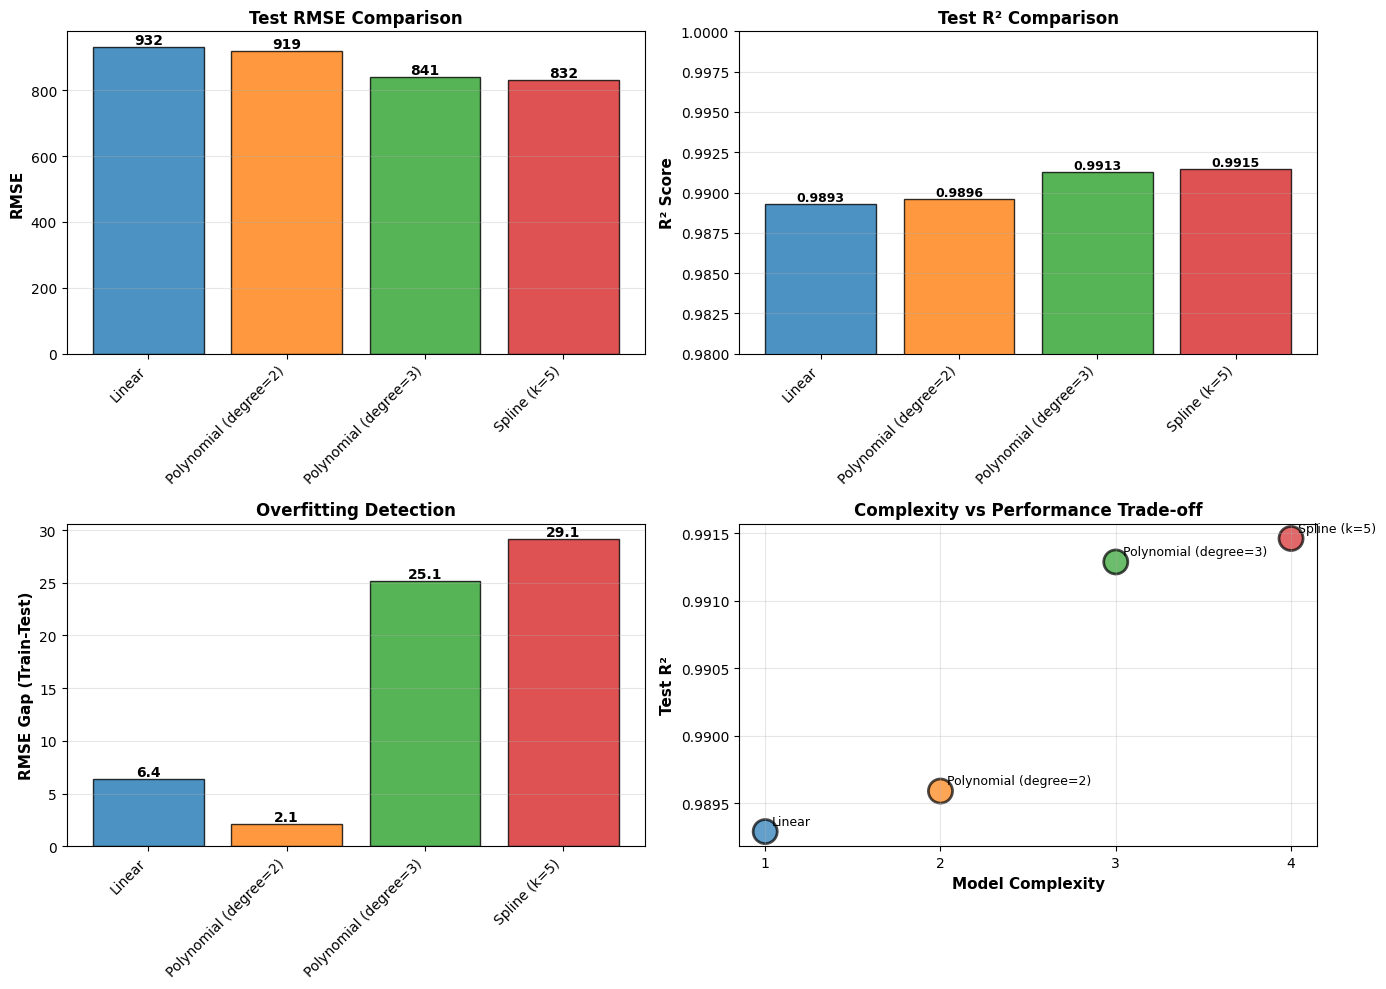


✓ Key Observations:
• Linear: Simple but may miss curved relationships
• Polynomial: Captures curves, but degree=3 may overfit
• Spline: Smooth curves with less overfitting risk
• Best model: Balance between accuracy and simplicity


In [5]:
# Visualize Model Comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Test RMSE Comparison
ax1 = axes[0, 0]
models_list = list(results.keys())
test_rmse = [results[m]['Test_RMSE'] for m in models_list]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
bars1 = ax1.bar(models_list, test_rmse, color=colors, alpha=0.8, edgecolor='black')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:.0f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylabel('RMSE', fontsize=11, fontweight='bold')
ax1.set_title('Test RMSE Comparison', fontsize=12, fontweight='bold')
ax1.set_xticklabels(models_list, rotation=45, ha='right')
ax1.grid(axis='y', alpha=0.3)

# Chart 2: R² Comparison
ax2 = axes[0, 1]
test_r2 = [results[m]['Test_R2'] for m in models_list]
bars2 = ax2.bar(models_list, test_r2, color=colors, alpha=0.8, edgecolor='black')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.4f}',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('R² Score', fontsize=11, fontweight='bold')
ax2.set_title('Test R² Comparison', fontsize=12, fontweight='bold')
ax2.set_ylim([0.98, 1.0])
ax2.set_xticklabels(models_list, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Chart 3: Overfitting Gap
ax3 = axes[1, 0]
overfitting = [results[m]['Overfitting'] for m in models_list]
bars3 = ax3.bar(models_list, overfitting, color=colors, alpha=0.8, edgecolor='black')
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3.set_ylabel('RMSE Gap (Train-Test)', fontsize=11, fontweight='bold')
ax3.set_title('Overfitting Detection', fontsize=12, fontweight='bold')
ax3.set_xticklabels(models_list, rotation=45, ha='right')
ax3.grid(axis='y', alpha=0.3)

# Chart 4: Model Complexity vs Performance
ax4 = axes[1, 1]
complexity = [1, 2, 3, 4]  # Linear, Poly2, Poly3, Spline
performance = test_r2
ax4.scatter(complexity, performance, s=300, c=colors, alpha=0.7, edgecolor='black', linewidth=2)
for i, model_name in enumerate(models_list):
    ax4.annotate(model_name, (complexity[i], performance[i]), 
                xytext=(5, 5), textcoords='offset points', fontsize=9)
ax4.set_xlabel('Model Complexity', fontsize=11, fontweight='bold')
ax4.set_ylabel('Test R²', fontsize=11, fontweight='bold')
ax4.set_title('Complexity vs Performance Trade-off', fontsize=12, fontweight='bold')
ax4.set_xticks(complexity)
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Key Observations:")
print("• Linear: Simple but may miss curved relationships")
print("• Polynomial: Captures curves, but degree=3 may overfit")
print("• Spline: Smooth curves with less overfitting risk")
print("• Best model: Balance between accuracy and simplicity")

In [3]:
# Data Preparation
# Drop non-numeric columns (8 categorical columns)
categorical_cols = ['Agriblock', 'Variety', 'Soil Types', 'Nursery', 
                    'Wind Direction_D1_D30', 'Wind Direction_D31_D60', 
                    'Wind Direction_D61_D90', 'Wind Direction_D91_D120']
X = df.drop(['Paddy yield(in Kg)'] + categorical_cols, axis=1)
y = df['Paddy yield(in Kg)']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")
print(f"Features: {len(X.columns)} numeric features")

Training set: (2231, 36)
Testing set: (558, 36)
Features: 36 numeric features


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load the paddy dataset
df = pd.read_csv('paddydataset.csv')

# Display dataset info
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset columns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (2789, 45)

First 5 rows:
   Hectares      Agriblock      Variety Soil Types  Seedrate(in Kg)  \
0          6     Cuddalore        CO_43   alluvial              150   
1          6   Kurinjipadi      ponmani       clay              150   
2          6       Panruti  delux ponni   alluvial              150   
3          6  Kallakurichi        CO_43       clay              150   
4          6  Sankarapuram      ponmani   alluvial              150   

   LP_Mainfield(in Tonnes) Nursery  Nursery area (Cents)  \
0                     75.0     dry                   120   
1                     75.0     wet                   120   
2                     75.0     dry                   120   
3                     75.0     wet                   120   
4                     75.0     dry                   120   

   LP_nurseryarea(in Tonnes)  DAP_20days  ...  Wind Direction_D1_D30  \
0                          6         240  ...                     SW   
1                          

# Non-Linear Regression: Complete Guide with Paddy Dataset

## What is Non-Linear Regression? (Feynman Explanation)

Imagine predicting rice yield with water and fertilizer:

**Linear Thinking (Wrong):**
"If 10 units of water → 100 kg yield, then 20 units → 200 kg"
❌ **Reality:** More water eventually drowns the crop! Doubling doesn't double yield.

**Non-Linear Thinking (Correct):**
"Yield increases with water, but at a SLOWER rate as water increases. It curves!"
✅ The relationship is curved, not straight.

### Real-World Non-Linear Examples:
- **Growth:** Baby weight growth is fastest initially, then slows down (exponential curve)
- **Diminishing Returns:** More fertilizer helps, but eventually you hit a ceiling (polynomial curve)
- **Learning:** Students learn faster early, then plateau (logarithmic curve)
- **Chemical Reactions:** Reaction speed depends on temperature in a curved way (exponential)

### The Key Insight
**Non-Linear Regression models curved relationships, not just straight lines**

Many real-world phenomena are fundamentally curved, not linear. Non-linear models capture this reality.